# NEXRAD over the OpenMesh network: rain days and snow days

OpenMesh publishes CMLs, personal weather stations and ASOS — but **no
radar**. There is no gridded reference to compare a CML-derived rainfall
field against, which is the one thing OpenMRG and OpenRainER both have.

`src/fetch/nexrad.py` fills that gap from **KOKX** (Upton, NY), the NEXRAD
covering New York City, via the Iowa Environmental Mesonet archive.

The interesting part is that winter matters here. The OpenMesh record spans
the 2023–24 winter, so the network saw both heavy rain and snow — and
reflectivity does not convert to a precipitation rate the same way for the
two.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from core.radar import nexrad

## Which days were rain, and which were snow?

Classified from METAR present-weather codes at the four NYC ASOS stations
(Central Park, LaGuardia, JFK, Newark) — `SN`/`SG`/`IC`/`PL` mark frozen
precipitation, `RA`/`DZ`/`TS` liquid. That is more reliable than a
temperature threshold, which mislabels the melting layer.

In [2]:
for kind in ("snow", "rain"):
    print(f"=== strongest {kind} days over the OpenMesh period ===")
    for d in nexrad.best_days(kind, 5):
        print(f"  {d.date}   {d.precip_mm:6.1f} mm   "
              f"snow obs {d.snow_obs:4d}   rain obs {d.rain_obs:4d}")
    print()

=== strongest snow days over the OpenMesh period ===


  2024-01-16      8.8 mm   snow obs  649   rain obs  278
  2024-02-13     16.8 mm   snow obs  527   rain obs  132
  2024-02-17      6.8 mm   snow obs  520   rain obs    0
  2024-01-06      3.9 mm   snow obs  188   rain obs   43
  2024-01-07     12.8 mm   snow obs  137   rain obs  736

=== strongest rain days over the OpenMesh period ===


  2024-03-23     84.1 mm   snow obs    0   rain obs  704
  2023-12-18     60.2 mm   snow obs    0   rain obs  703
  2023-11-22     50.9 mm   snow obs    0   rain obs  532
  2024-01-10     41.0 mm   snow obs    0   rain obs  337
  2023-12-28     40.3 mm   snow obs    0   rain obs  717



Two of the snow days — 2024-01-16 and 2024-01-19 — fall inside the OpenMesh
20-day example subset, so radar and CML can be compared directly on the same
hours.

## Why rain and snow need different conversions

Radar measures reflectivity `Z`, not precipitation. The conversion is a power
law, and the coefficients differ: snow of a given *liquid-water-equivalent*
rate scatters far more than rain at the same rate.

| | relation | |
|---|---|---|
| rain | `Z = 200 R^1.6` | Marshall-Palmer |
| snow | `Z = 180 S^2.0` | Sekhon-Srivastava, the WSR-88D operational pair |

Using the rain relation on a snow day overstates the rate — badly, at the
high end.

  20 dBZ  ->  rain   0.65 mm/h   snow   0.75 mm/h   (rain is 0.9x)
  30 dBZ  ->  rain   2.73 mm/h   snow   2.36 mm/h   (rain is 1.2x)
  40 dBZ  ->  rain  11.53 mm/h   snow   7.45 mm/h   (rain is 1.5x)


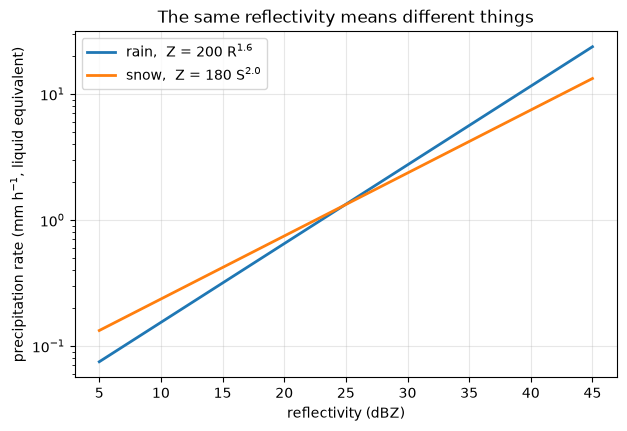

In [3]:
dbz = np.linspace(5, 45, 100)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dbz, nexrad.to_rate(dbz, "rain"), lw=2, label="rain,  Z = 200 R$^{1.6}$")
ax.plot(dbz, nexrad.to_rate(dbz, "snow"), lw=2, label="snow,  Z = 180 S$^{2.0}$")
ax.set_xlabel("reflectivity (dBZ)")
ax.set_ylabel("precipitation rate (mm h$^{-1}$, liquid equivalent)")
ax.set_yscale("log")
ax.set_title("The same reflectivity means different things")
ax.legend()
ax.grid(alpha=0.3)

for z in (20, 30, 40):
    r, s = nexrad.to_rate(z, "rain"), nexrad.to_rate(z, "snow")
    print(f"  {z} dBZ  ->  rain {r:6.2f} mm/h   snow {s:6.2f} mm/h   "
          f"(rain is {r / s:.1f}x)")

## Loading a day

Each day is cached as a netCDF holding `dbz` and the derived rate `R`, on a
~1.2 km grid over the network.

In [4]:
snow = nexrad.build_day("2024-01-16", "snow")
rain = nexrad.build_day("2024-03-23", "rain")

for name, ds in [("snow 2024-01-16", snow), ("rain 2024-03-23", rain)]:
    r = np.asarray(ds.R)
    print(f"{name}: {ds.sizes['time']} frames, grid "
          f"{ds.sizes['lat']}x{ds.sizes['lon']}, "
          f"peak {np.nanmax(r):5.1f} mm/h, "
          f"domain mean {np.nanmean(r):.3f} mm/h")

  [cache] nexrad_OKX_N0B_2024-01-16_snow.nc


  [cache] nexrad_OKX_N0B_2024-03-23_rain.nc
snow 2024-01-16: 206 frames, grid 34x28, peak   7.9 mm/h, domain mean 0.508 mm/h
rain 2024-03-23: 205 frames, grid 34x28, peak  80.5 mm/h, domain mean 3.312 mm/h


## The two days side by side

Accumulation over the day, with the OpenMesh links drawn on top.

  [skip]  openmesh_cml_20d.nc  (0.91 MB, already present)


  [skip]  openmesh_wu_pws_20d.nc  (2.04 MB, already present)


  [skip]  openmesh_asos_ws_20d.nc  (3.73 MB, already present)


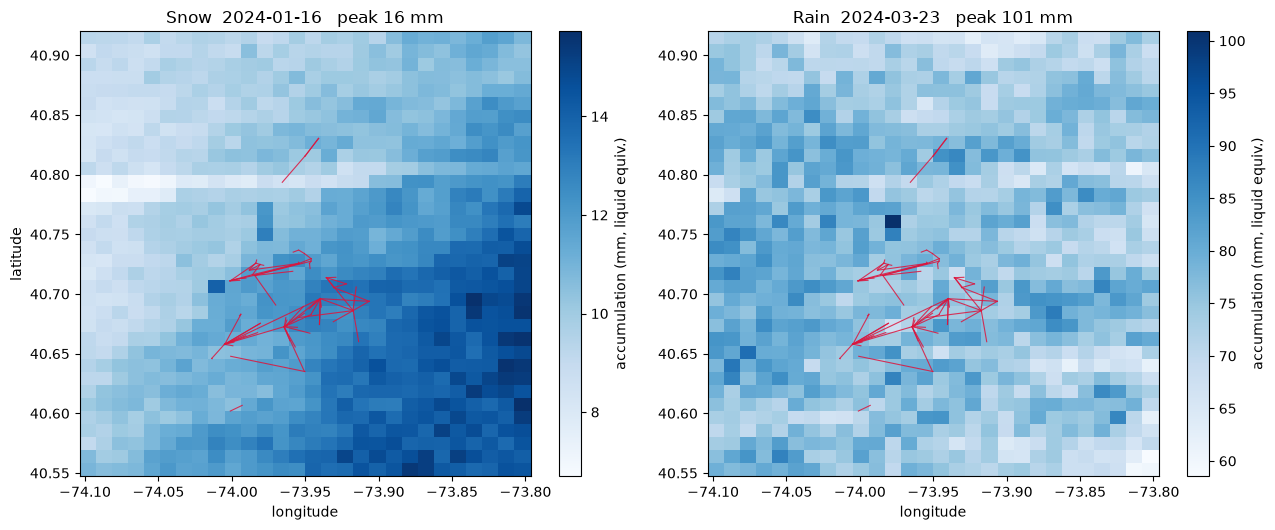

In [5]:
from core.opensense import example_data

cml = example_data.load("openmesh", "20d")["cml"]
x0, y0 = np.asarray(cml.site_0_lon), np.asarray(cml.site_0_lat)
x1, y1 = np.asarray(cml.site_1_lon), np.asarray(cml.site_1_lat)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))

for ax, (label, ds) in zip(axes, [("Snow  2024-01-16", snow),
                                  ("Rain  2024-03-23", rain)]):
    hours = float((np.diff(ds.time.values[:2]) / np.timedelta64(1, "h"))[0])
    total = np.nansum(np.asarray(ds.R), axis=0) * hours

    m = ax.pcolormesh(ds.lon, ds.lat, total, shading="nearest", cmap="Blues")
    for a, b, c, d in zip(x0, y0, x1, y1):
        ax.plot([a, c], [b, d], color="crimson", lw=0.8, alpha=0.85)
    plt.colorbar(m, ax=ax, label="accumulation (mm, liquid equiv.)")
    ax.set_title(f"{label}   peak {np.nanmax(total):.0f} mm")
    ax.set_xlabel("longitude")
axes[0].set_ylabel("latitude")
plt.tight_layout()

The link network (red) sits inside the radar footprint, so every link has a
gridded reference above it — which is what was missing before.

## Time series over the network

Averaging the radar only over pixels the links actually cover.

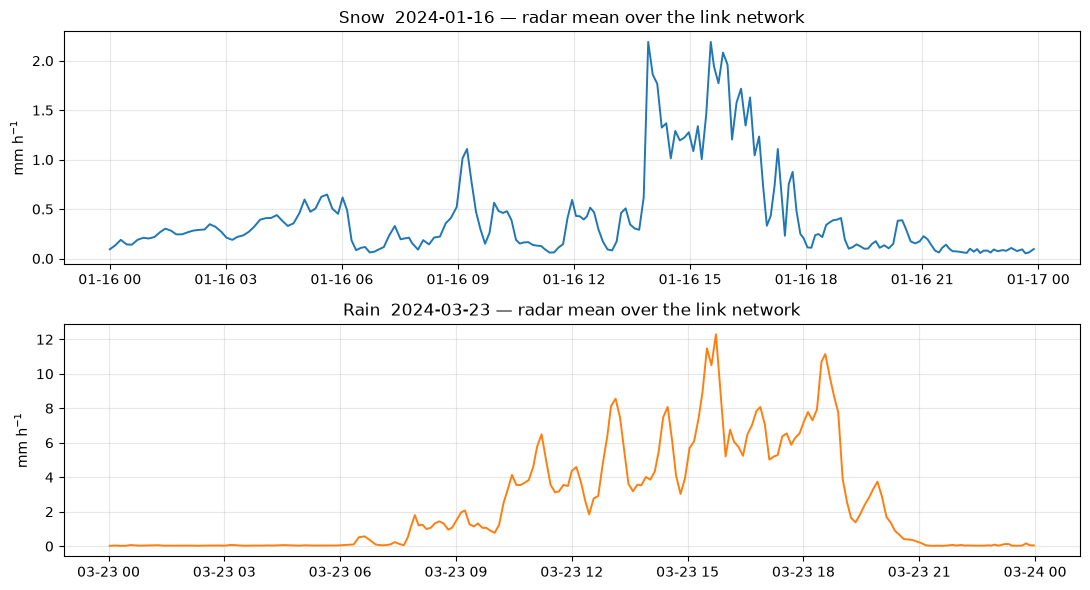

In [6]:
lon_lo, lon_hi = min(x0.min(), x1.min()), max(x0.max(), x1.max())
lat_lo, lat_hi = min(y0.min(), y1.min()), max(y0.max(), y1.max())

fig, axes = plt.subplots(2, 1, figsize=(11, 6))

for ax, (label, ds, color) in zip(axes, [("Snow  2024-01-16", snow, "tab:blue"),
                                         ("Rain  2024-03-23", rain, "tab:orange")]):
    sub = ds.sel(lon=slice(lon_lo, lon_hi), lat=slice(lat_hi, lat_lo))
    if sub.sizes["lat"] == 0:
        sub = ds.sel(lon=slice(lon_lo, lon_hi), lat=slice(lat_lo, lat_hi))
    series = sub.R.mean(dim=["lat", "lon"])
    ax.plot(sub.time, series, color=color, lw=1.4)
    ax.set_ylabel("mm h$^{-1}$")
    ax.set_title(f"{label} — radar mean over the link network")
    ax.grid(alpha=0.3)
plt.tight_layout()

## Fetching more

```bash
# what is available
python projects/openmesh_nyc/src/fetch/nexrad.py --classify

# one day, kind inferred from METAR
python projects/openmesh_nyc/src/fetch/nexrad.py --date 2024-02-13

# the three strongest snow days
python projects/openmesh_nyc/src/fetch/nexrad.py --best 3 --kind snow
```

About 1.6 MB per day at 5-minute spacing. The native cadence is 2–5 minutes;
`--step` thins it.

### Caveats worth carrying forward

- **Reflectivity is aloft, not at the ground.** KOKX's beam is several
  hundred metres up over the city, and in snow the difference between what
  the beam sees and what reaches the street is larger than in rain.
- **Snow rates are liquid-water equivalent.** Multiply by roughly 10 for
  snow depth, and that ratio itself varies with temperature.
- **`Z = 180 S^2.0` is one choice among many.** Published snow relations
  disagree by a factor of two or more; this one is the WSR-88D operational
  pair, not a universal truth.
